# BloodCell Classifier — Progetto BloodMNIST (Adversarial Training)
**MobileNetV2 "KevlarNet" — leggera come una MobileNet, resistente come un giubbotto antiproiettile**

Questo notebook implementa:
- **Fase 0**: Analisi dell'Agente e dell'Ambiente
- **Fase 1**: Preparazione e analisi del dataset BloodMNIST
- **Fase 2**: Addestramento CNN (MobileNetV2) base tramite Grid Search
- **Fase 2b/c**: Attacchi FGSM/PGD e **Adversarial Fine-Tuning** per aumentare drasticamente la robustezza
- **Fase 3**: Valutazione del modello corazzato (Matrici di confusione, curve epsilon)
- **Componente Avanzata**: Grad-CAM per verificare che il modello si concentri sulle reali strutture cellulari e non su artefatti di sfondo.


In [ ]:
# ── Installazione dipendenze ──────────────────────────────────────────────────
!pip install medmnist torchcam grad-cam matplotlib seaborn scikit-learn tqdm -q


In [1]:
# ── Import librerie ───────────────────────────────────────────────────────────
import os
import pickle
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import warnings
import cv2
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import medmnist
from medmnist import BloodMNIST, INFO

from sklearn.metrics import confusion_matrix, f1_score
from sklearn.preprocessing import label_binarize

# Riproducibilità
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps'  if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'MedMNIST versione: {medmnist.__version__}')

# ── Cartelle di output ────────────────────────────────────────────────────────
# Path assoluto e fisso alla repo: `_dh[0]` in IPython NON è la cartella del
# notebook, è solo la cwd con cui è partito il kernel (stessa cosa di
# os.getcwd()) — motivo per cui il tentativo precedente falliva comunque se
# Jupyter veniva lanciato dalla home. Con un path assoluto il problema sparisce
# indipendentemente da dove viene avviato il kernel.
REPO_ROOT  = '/Users/antoniomelis/Documents/GitHub/IAS'
MODELS_DIR = os.path.join(REPO_ROOT, 'modelli')
IMAGES_DIR = os.path.join(REPO_ROOT, 'immagini')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)
print(f'Cartella checkpoint: {MODELS_DIR}')
print(f'Cartella immagini:   {IMAGES_DIR}')


Dispositivo: mps
MedMNIST versione: 3.0.2
Cartella checkpoint: /Users/antoniomelis/Documents/GitHub/IAS/modelli
Cartella immagini:   /Users/antoniomelis/Documents/GitHub/IAS/immagini


## Fase 0 — Analisi Agente e Ambiente

### Agente: KevlarNet (MobileNetV2, Robust version)
| Proprietà | Descrizione |
|-----------|-------------|
| **Tipo** | Agente reattivo basato su modello |
| **Percezioni** | Immagini RGB 28x28 px (ridimensionate a 224) |
| **Azioni** | Output di una distribuzione di probabilità su 8 classi |
| **Obiettivo** | Classificazione accurata e **robusta alle perturbazioni** per supporto diagnostico, con un'impronta computazionale leggera |
| **Architettura** | MobileNetV2 fine-tuned + Adversarial Training |

### Perché "KevlarNet"?
MobileNetV2 nasce per essere leggera e veloce (ideale per dispositivi mobili/edge), ma di norma è anche più fragile agli attacchi avversariali rispetto a reti più capienti come ResNet-18. Con l'Adversarial Fine-Tuning la rendiamo "corazzata" senza appesantirla: da qui il nome **KevlarNet** — leggera da indossare, difficile da bucare.

### Caratteristiche dell'Ambiente (PEAS)
Parzialmente osservabile, Stocastico, Episodico, Statico, Discreto, Singolo agente.


In [2]:

info = INFO['bloodmnist']
print('\n=== INFO BloodMNIST ===')
print(f"Task: {info['task']}")
print(f"N. classi: {len(info['label'])}")
print(f"Classi: {info['label']}")

CLASS_NAMES = list(info['label'].values())

# Augmentation e batch size allineati al notebook "BloodMNIST - MobileNetV2.ipynb"
# (vanilla), per rendere il confronto KevlarNet-vs-vanilla il più fair possibile.
BATCH_SIZE = 64

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = BloodMNIST(split='train', transform=transform_train, download=True, size=224)
val_dataset   = BloodMNIST(split='val',   transform=transform_test,  download=True, size=224)
test_dataset  = BloodMNIST(split='test',  transform=transform_test,  download=True, size=224)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nDataset caricato: Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')



=== INFO BloodMNIST ===
Task: multi-class
N. classi: 8
Classi: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}

Dataset caricato: Train: 11959 | Val: 1712 | Test: 3421


## Fase 2 — Addestramento CNN Standard (Grid Search)
Addestriamo una MobileNetV2 sulle immagini pulite per trovare la combinazione migliore di iperparametri. Successivamente la sottoporremo ad *Adversarial Fine-Tuning* per trasformarla in **KevlarNet**.


  [1/8] ep  1/10 tr=0.8366 vl=0.9381


  [1/8] ep  2/10 tr=0.9062 vl=0.9381


  [1/8] ep  3/10 tr=0.9150 vl=0.9451


  [1/8] ep  4/10 tr=0.9155 vl=0.9568


  [1/8] ep  5/10 tr=0.9437 vl=0.9761


...

  [8/8] ep  6/10 tr=0.9094 vl=0.9574


  [8/8] ep  7/10 tr=0.9343 vl=0.9708


  [8/8] ep  8/10 tr=0.9445 vl=0.9720


  [8/8] ep  9/10 tr=0.9440 vl=0.9737


  [8/8] ep 10/10 tr=0.9472 vl=0.9737
✓ Grid search completata: vince la configurazione #2 — salvata in /Users/antoniomelis/Documents/GitHub/IAS/modelli/gs_history_mobilenetv2.pkl


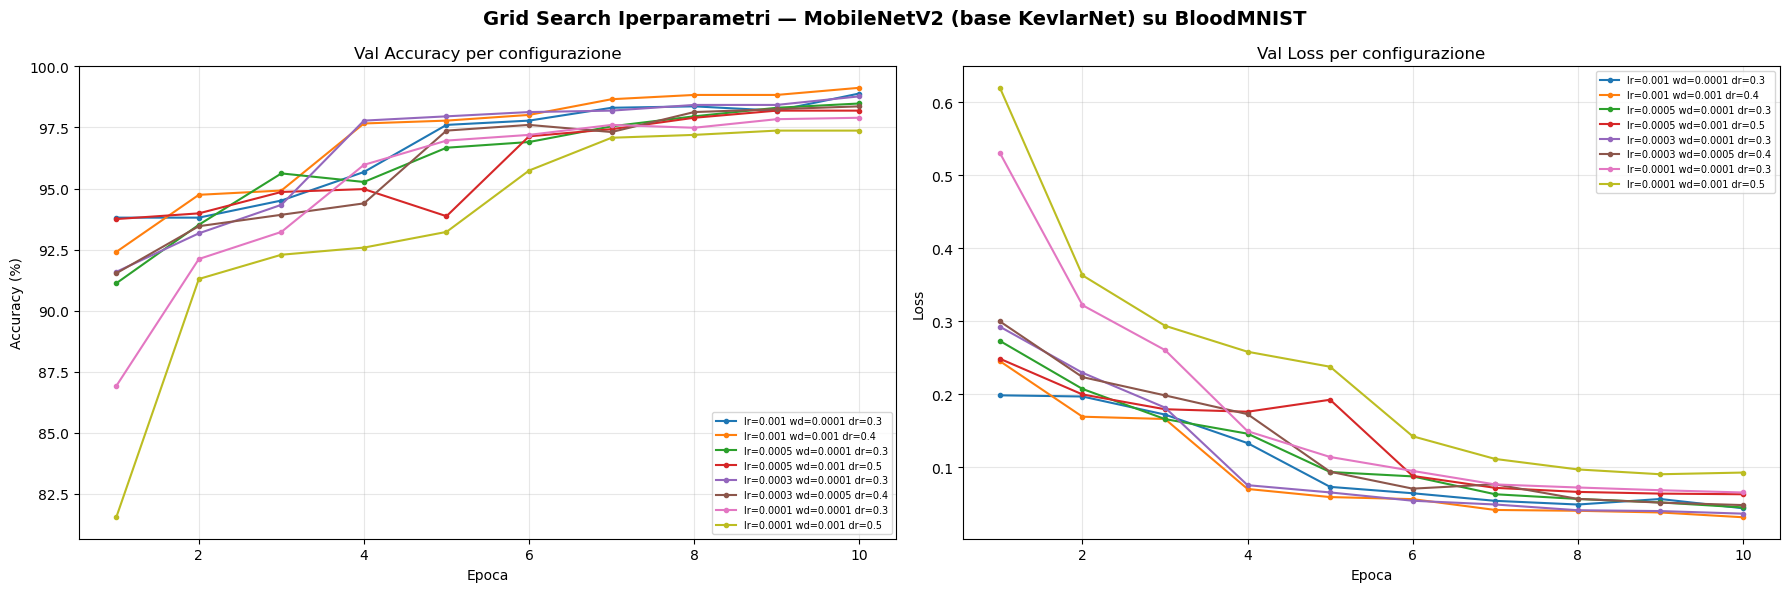


  # |       LR |       WD |  Dropout | Unfrz E | Unfrz B |   Val Acc
------------------------------------------------------------------------
  1 |    0.001 |   0.0001 |      0.3 |       4 |       4 |   98.89%
  2 |    0.001 |    0.001 |      0.4 |       3 |       4 |   99.12%  <-- BEST
  3 |   0.0005 |   0.0001 |      0.3 |       4 |       3 |   98.48%
  4 |   0.0005 |    0.001 |      0.5 |       5 |       3 |   98.19%
  5 |   0.0003 |   0.0001 |      0.3 |       3 |       5 |   98.77%
  6 |   0.0003 |   0.0005 |      0.4 |       4 |       4 |   98.36%
  7 |   0.0001 |   0.0001 |      0.3 |       3 |       4 |   97.90%
  8 |   0.0001 |    0.001 |      0.5 |       5 |       5 |   97.37%

Miglior Configurazione Trovata: {'lr': 0.001, 'weight_decay': 0.001, 'dropout': 0.4, 'unfreeze_every': 3, 'unfreeze_blocks': 4}
Blocchi features sbloccati: 12/19 | Parametri allenabili: 2,498,376/2,553,864 (97.8%)
Checkpoint grid search: /Users/antoniomelis/Documents/GitHub/IAS/modelli/gs_best_mobilen

In [3]:

def build_model(num_classes=8, pretrained=True, dropout=0.3):
    model = models.mobilenet_v2(weights='IMAGENET1K_V1' if pretrained else None)
    for param in model.features.parameters(): param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=dropout * 0.67),
        nn.Linear(256, num_classes)
    )
    return model

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

GS_CKPT_PATH       = os.path.join(MODELS_DIR, 'gs_best_mobilenetv2.pth')
GS_HISTORY_PATH    = os.path.join(MODELS_DIR, 'gs_history_mobilenetv2.pkl')
ADV_CKPT_PATH      = os.path.join(MODELS_DIR, 'kevlarnet_best.pth')
FORCE_RECOMPUTE_GS = False  # True per rifare la grid search anche se esiste già un checkpoint

if os.path.exists(ADV_CKPT_PATH) and not FORCE_RECOMPUTE_GS:
    
    print(f'✓ KevlarNet già pronta ({ADV_CKPT_PATH}): grid search saltata, non serve per la valutazione.')
    model = build_model(dropout=0.3).to(DEVICE)
    gs_results = []
else:
    
    GS_CONFIGS = [
        {'lr': 1e-3,  'weight_decay': 1e-4, 'dropout': 0.3, 'unfreeze_every': 4, 'unfreeze_blocks': 4},
        {'lr': 1e-3,  'weight_decay': 1e-3, 'dropout': 0.4, 'unfreeze_every': 3, 'unfreeze_blocks': 4},
        {'lr': 5e-4,  'weight_decay': 1e-4, 'dropout': 0.3, 'unfreeze_every': 4, 'unfreeze_blocks': 3},
        {'lr': 5e-4,  'weight_decay': 1e-3, 'dropout': 0.5, 'unfreeze_every': 5, 'unfreeze_blocks': 3},
        {'lr': 3e-4,  'weight_decay': 1e-4, 'dropout': 0.3, 'unfreeze_every': 3, 'unfreeze_blocks': 5},
        {'lr': 3e-4,  'weight_decay': 5e-4, 'dropout': 0.4, 'unfreeze_every': 4, 'unfreeze_blocks': 4},
        {'lr': 1e-4,  'weight_decay': 1e-4, 'dropout': 0.3, 'unfreeze_every': 3, 'unfreeze_blocks': 4},
        {'lr': 1e-4,  'weight_decay': 1e-3, 'dropout': 0.5, 'unfreeze_every': 5, 'unfreeze_blocks': 5},
    ]

    GS_EPOCHS   = 10
    GS_PATIENCE = 3

    def run_config(cfg, tag, ckpt_path):
        
        m = build_model(dropout=cfg['dropout']).to(DEVICE)
        crit = nn.CrossEntropyLoss()
        opt = optim.AdamW(filter(lambda p: p.requires_grad, m.parameters()), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=GS_EPOCHS)
        best_acc, best_loss, es_counter = 0.0, float('inf'), 0
        best_frz_from = None
        hist = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

        n_feats = len(m.features)
        frz_from = n_feats

        for epoch in range(1, GS_EPOCHS + 1):
            if epoch > 1 and (epoch - 1) % cfg['unfreeze_every'] == 0 and frz_from > 0:
                new_frz = max(0, frz_from - cfg['unfreeze_blocks'])
                new_params = []
                for i in range(new_frz, frz_from):
                    for p in m.features[i].parameters():
                        p.requires_grad = True
                        new_params.append(p)
                if new_params:
                    opt.add_param_group({'params': new_params, 'lr': cfg['lr'] * 0.1})
                frz_from = new_frz

            tr_loss, tr_acc = train_one_epoch(m, train_loader, opt, crit)
            vl_loss, vl_acc, _, _ = evaluate(m, val_loader, crit)
            sched.step()
            hist['train_acc'].append(tr_acc); hist['val_acc'].append(vl_acc)
            hist['train_loss'].append(tr_loss); hist['val_loss'].append(vl_loss)

            if vl_acc > best_acc:
                best_acc = vl_acc
                best_frz_from = frz_from
                torch.save(m.state_dict(), ckpt_path)
            if vl_loss < best_loss:
                best_loss = vl_loss; es_counter = 0
            else:
                es_counter += 1

            print(f'  [{tag}] ep {epoch:2d}/{GS_EPOCHS} tr={tr_acc:.4f} vl={vl_acc:.4f}')
            if es_counter >= GS_PATIENCE: break
        return best_acc, best_frz_from, hist

    
    _gs_skip = (os.path.exists(GS_CKPT_PATH) and os.path.exists(GS_HISTORY_PATH))

    if _gs_skip:
        with open(GS_HISTORY_PATH, 'rb') as f:
            gs_results = pickle.load(f)
        print(f'✓ Grid search caricata da checkpoint ({len(gs_results)} configurazioni) — {GS_CKPT_PATH}')
    else:
        gs_results = []
        tmp_ckpts = []
        for i, cfg in enumerate(GS_CONFIGS):
            tmp_ckpt = os.path.join(MODELS_DIR, f'_gs_tmp_cfg{i}_mobilenetv2.pth')
            tmp_ckpts.append(tmp_ckpt)
            best_acc, best_frz_from, hist = run_config(cfg, f'{i+1}/{len(GS_CONFIGS)}', tmp_ckpt)
            gs_results.append({'cfg': cfg, 'best_val_acc': best_acc, 'best_frz_from': best_frz_from, 'history': hist})

        
        _winner_idx = max(range(len(gs_results)), key=lambda i: gs_results[i]['best_val_acc'])
        shutil.copy2(tmp_ckpts[_winner_idx], GS_CKPT_PATH)
        for tp in tmp_ckpts:
            if os.path.exists(tp):
                os.remove(tp)

        with open(GS_HISTORY_PATH, 'wb') as f:
            pickle.dump(gs_results, f)
        print(f'✓ Grid search completata: vince la configurazione #{_winner_idx + 1} — salvata in {GS_HISTORY_PATH}')

    # Confronto configurazioni
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    colors_gs = plt.cm.tab10(np.linspace(0, 0.8, len(GS_CONFIGS)))

    for i, res in enumerate(gs_results):
        cfg  = res['cfg']
        hist = res['history']
        lbl  = f"lr={cfg['lr']} wd={cfg['weight_decay']} dr={cfg['dropout']}"
        ep   = range(1, len(hist['val_acc']) + 1)
        axes[0].plot(ep, [a * 100 for a in hist['val_acc']], '-o', color=colors_gs[i], label=lbl, ms=3, lw=1.5)
        axes[1].plot(ep, hist['val_loss'], '-o', color=colors_gs[i], label=lbl, ms=3, lw=1.5)

    for ax, title, ylabel in zip(axes,
                                  ['Val Accuracy per configurazione', 'Val Loss per configurazione'],
                                  ['Accuracy (%)', 'Loss']):
        ax.set_title(title, fontsize=12); ax.set_xlabel('Epoca'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=7, loc='lower right' if 'Acc' in title else 'upper right')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Grid Search Iperparametri — MobileNetV2 (base KevlarNet) su BloodMNIST',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'gs_comparison_kevlarnet.png'), dpi=150, bbox_inches='tight')
    plt.show()

    max_acc = max(r['best_val_acc'] for r in gs_results)
    print(f'\n{"#":>3} | {"LR":>8} | {"WD":>8} | {"Dropout":>8} | {"Unfrz E":>7} | {"Unfrz B":>7} | {"Val Acc":>9}')
    print('-' * 72)
    best_gs_idx = 0
    for i, res in enumerate(gs_results):
        cfg  = res['cfg']
        mark = '  <-- BEST' if res['best_val_acc'] == max_acc else ''
        print(f'{i+1:>3} | {cfg["lr"]:>8} | {cfg["weight_decay"]:>8} | '
              f'{cfg["dropout"]:>8.1f} | {cfg["unfreeze_every"]:>7} | '
              f'{cfg["unfreeze_blocks"]:>7} | {res["best_val_acc"]:>8.2%}{mark}')
        if res['best_val_acc'] == max_acc:
            best_gs_idx = i

    BEST_GS  = gs_results[best_gs_idx]
    BEST_CFG = BEST_GS['cfg']

    model = build_model(dropout=BEST_CFG['dropout']).to(DEVICE)
    model.load_state_dict(torch.load(GS_CKPT_PATH, map_location=DEVICE))

    
    n_feats = len(model.features)
    frz_from = BEST_GS['best_frz_from'] if BEST_GS['best_frz_from'] is not None else n_feats
    for i in range(frz_from, n_feats):
        for p in model.features[i].parameters():
            p.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"\nMiglior Configurazione Trovata: {BEST_CFG}")
    print(f'Blocchi features sbloccati: {n_feats - frz_from}/{n_feats} | Parametri allenabili: {trainable:,}/{total:,} ({100*trainable/total:.1f}%)')
    print(f'Checkpoint grid search: {GS_CKPT_PATH}')


## Fase 2b — Definizione Attacchi Avversariali e Adversarial Fine-Tuning
Ora definiamo le perturbazioni FGSM e PGD. Addestreremo il modello ad essere immune a queste perturbazioni, trasformando la MobileNetV2 base in **KevlarNet**.


In [4]:
criterion = nn.CrossEntropyLoss()
THAL_CLASSES = {2: 'eritroblasto', 3: 'gr. immaturo', 7: 'piastrina'}

def fgsm_attack(model, images, labels, epsilon, criterion):
    images_adv = images.clone().requires_grad_(True)
    outputs = model(images_adv)
    loss = criterion(outputs, labels)
    model.zero_grad()
    loss.backward()
    return images_adv.detach() + epsilon * images_adv.grad.sign()

def pgd_attack(model, images, labels, epsilon, alpha, n_steps, criterion):
    images_adv = images.clone() + torch.empty_like(images).uniform_(-epsilon, epsilon)
    images_adv = torch.clamp(images_adv, images.min(), images.max())
    for _ in range(n_steps):
        images_adv.requires_grad_(True)
        outputs = model(images_adv)
        loss = criterion(outputs, labels)
        model.zero_grad()
        loss.backward()
        images_adv = images_adv.detach() + alpha * images_adv.grad.sign()
        delta = torch.clamp(images_adv - images, -epsilon, epsilon)
        images_adv = images + delta
    return images_adv.detach()

def evaluate_adversarial_pgd(model, loader, epsilon, alpha, n_steps, criterion, n_classes=8):
    # Restituisce anche preds/labels grezzi (oltre ad accuracy globale/per-classe)
    # cosi' si puo' calcolare F1-macro/weighted a ogni epsilon senza rilanciare
    # l'attacco una seconda volta (il PGD a 10 step e' il pezzo piu' costoso).
    model.eval()
    correct, total = 0, 0
    per_class_correct = np.zeros(n_classes); per_class_total = np.zeros(n_classes)
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)
        imgs_adv = pgd_attack(model, imgs, labels, epsilon, alpha, n_steps, criterion)
        with torch.no_grad(): outputs = model(imgs_adv)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item(); total += imgs.size(0)
        for c in range(n_classes):
            mask = (labels == c)
            per_class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            per_class_total[c] += mask.sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    per_class_acc = np.divide(per_class_correct, per_class_total, out=np.zeros_like(per_class_correct), where=per_class_total > 0)
    return correct / total, per_class_acc, np.array(all_preds), np.array(all_labels)

def evaluate_adversarial_fgsm(model, loader, epsilon, criterion, n_classes=8):
    model.eval()
    correct, total = 0, 0
    per_class_correct = np.zeros(n_classes); per_class_total = np.zeros(n_classes)
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)
        if epsilon == 0:
            imgs_adv = imgs
        else:
            imgs_adv = fgsm_attack(model, imgs, labels, epsilon, criterion)
        with torch.no_grad(): outputs = model(imgs_adv)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item(); total += imgs.size(0)
        for c in range(n_classes):
            mask = (labels == c)
            per_class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            per_class_total[c] += mask.sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    per_class_acc = np.divide(per_class_correct, per_class_total, out=np.zeros_like(per_class_correct), where=per_class_total > 0)
    return correct / total, per_class_acc, np.array(all_preds), np.array(all_labels)


In [5]:
print('\nADVERSARIAL FINE-TUNING (MobileNetV2 → KevlarNet)')

def train_one_epoch_adv(model, loader, optimizer, criterion, adv_eps=0.05, adv_alpha=0.0125, adv_steps=5):
    """Training misto: 50% accuratezza pulita, 50% robustezza su PGD."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Adv Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)

        # Genera perturbazioni on-the-fly in modalità eval
        model.eval()
        imgs_adv = pgd_attack(model, imgs, labels, adv_eps, adv_alpha, adv_steps, criterion)
        model.train()

        optimizer.zero_grad()
        outputs_clean = model(imgs)
        outputs_adv = model(imgs_adv)

        loss = 0.5 * criterion(outputs_clean, labels) + 0.5 * criterion(outputs_adv, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (outputs_adv.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

ADV_EPOCHS = 8
TRAIN_EPS  = 0.05
TRAIN_ALFA = 0.0125
TRAIN_STEP = 5
ADV_CKPT_PATH        = os.path.join(MODELS_DIR, 'kevlarnet_best.pth')
FORCE_RECOMPUTE_ADV  = False  # True per rifare fine-tuning 

if not FORCE_RECOMPUTE_ADV and os.path.exists(ADV_CKPT_PATH):
    print(f'✓ KevlarNet già addestrata, carico i pesi da {ADV_CKPT_PATH} (training saltato)')
    model.load_state_dict(torch.load(ADV_CKPT_PATH, map_location=DEVICE))
else:
    opt_adv = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=1e-3)
    sched_adv = optim.lr_scheduler.CosineAnnealingLR(opt_adv, T_max=ADV_EPOCHS)
    best_adv_acc = -1.0  

    for epoch in range(1, ADV_EPOCHS + 1):
        tr_loss, tr_adv_acc = train_one_epoch_adv(model, train_loader, opt_adv, criterion, adv_eps=TRAIN_EPS, adv_alpha=TRAIN_ALFA, adv_steps=TRAIN_STEP)
        val_clean_loss, val_clean_acc, _, _ = evaluate(model, val_loader, criterion)
        val_adv_acc, _, _, _ = evaluate_adversarial_pgd(model, val_loader, TRAIN_EPS, TRAIN_ALFA, TRAIN_STEP, criterion)
        sched_adv.step()

        print(f'Epoca [{epoch}/{ADV_EPOCHS}] | Mix Loss: {tr_loss:.4f} | Val Clean: {val_clean_acc*100:.2f}% | Val Adv (PGD): {val_adv_acc*100:.2f}%')

        if val_adv_acc > best_adv_acc:
            best_adv_acc = val_adv_acc
            torch.save(model.state_dict(), ADV_CKPT_PATH)

    print(f'\nCaricamento di KevlarNet (MobileNetV2 corazzata) definitivo per la validazione da {ADV_CKPT_PATH}...')
    model.load_state_dict(torch.load(ADV_CKPT_PATH, map_location=DEVICE))



ADVERSARIAL FINE-TUNING (MobileNetV2 → KevlarNet)


Epoca [1/8] | Mix Loss: 2.4630 | Val Clean: 90.19% | Val Adv (PGD): 21.32%


Epoca [2/8] | Mix Loss: 1.2097 | Val Clean: 90.65% | Val Adv (PGD): 27.86%


Epoca [3/8] | Mix Loss: 0.9010 | Val Clean: 91.30% | Val Adv (PGD): 31.48%


Epoca [4/8] | Mix Loss: 0.7391 | Val Clean: 89.08% | Val Adv (PGD): 33.47%


Epoca [5/8] | Mix Loss: 0.6634 | Val Clean: 89.19% | Val Adv (PGD): 33.24%


Epoca [6/8] | Mix Loss: 0.6421 | Val Clean: 91.82% | Val Adv (PGD): 31.66%


Epoca [7/8] | Mix Loss: 0.6470 | Val Clean: 93.22% | Val Adv (PGD): 32.59%


Epoca [8/8] | Mix Loss: 0.5809 | Val Clean: 92.93% | Val Adv (PGD): 32.30%

Caricamento di KevlarNet (MobileNetV2 corazzata) definitivo per la validazione da /Users/antoniomelis/Documents/GitHub/IAS/modelli/kevlarnet_best.pth...


In [6]:

# Fine-Tuning abbia davvero cambiato la robustezza rispetto al punto di partenza.
model_pre_adv = build_model(dropout=0.3).to(DEVICE)
model_pre_adv.load_state_dict(torch.load(GS_CKPT_PATH, map_location=DEVICE))
model_pre_adv.eval()
print(f'✓ Modello pre-finetuning (solo Grid Search) caricato da {GS_CKPT_PATH}')


✓ Modello pre-finetuning (solo Grid Search) caricato da /Users/antoniomelis/Documents/GitHub/IAS/modelli/gs_best_mobilenetv2.pth


## Fase 3 — Analisi Risultati (sul Modello Robusto)
Valutiamo come l'Adversarial Training ha "appiattito" la curva di deterioramento di KevlarNet.



=== Valutazione FGSM e PGD vs Epsilon — KevlarNet vs pre-finetuning ===
ε=0.00 → KevlarNet: FGSM 89.21% PGD 89.21%  |  Pre-FT: FGSM 98.57% PGD 98.57%
ε=0.01 → KevlarNet: FGSM 74.54% PGD 66.71%  |  Pre-FT: FGSM 34.00% PGD  0.06%
ε=0.02 → KevlarNet: FGSM 70.13% PGD 44.93%  |  Pre-FT: FGSM 27.86% PGD  0.00%
ε=0.05 → KevlarNet: FGSM 65.48% PGD 19.99%  |  Pre-FT: FGSM 31.57% PGD  0.00%
ε=0.10 → KevlarNet: FGSM 61.15% PGD  9.12%  |  Pre-FT: FGSM 34.93% PGD  0.00%
ε=0.20 → KevlarNet: FGSM 53.29% PGD  0.64%  |  Pre-FT: FGSM 21.10% PGD  0.00%

FGSM — F1-macro / F1-weighted vs ε
     ε |  acc pre |  F1m pre |  F1w pre | acc Kevlar | F1m Kevlar | F1w Kevlar
------------------------------------------------------------------------------
  0.00 |   98.57% |   0.9860 |   0.9857 |     89.21% |     0.8665 |     0.8876
  0.01 |   34.00% |   0.2990 |   0.3614 |     74.54% |     0.6578 |     0.7149
  0.02 |   27.86% |   0.2541 |   0.3031 |     70.13% |     0.6067 |     0.6654
  0.05 |   31.57% |   0.2787

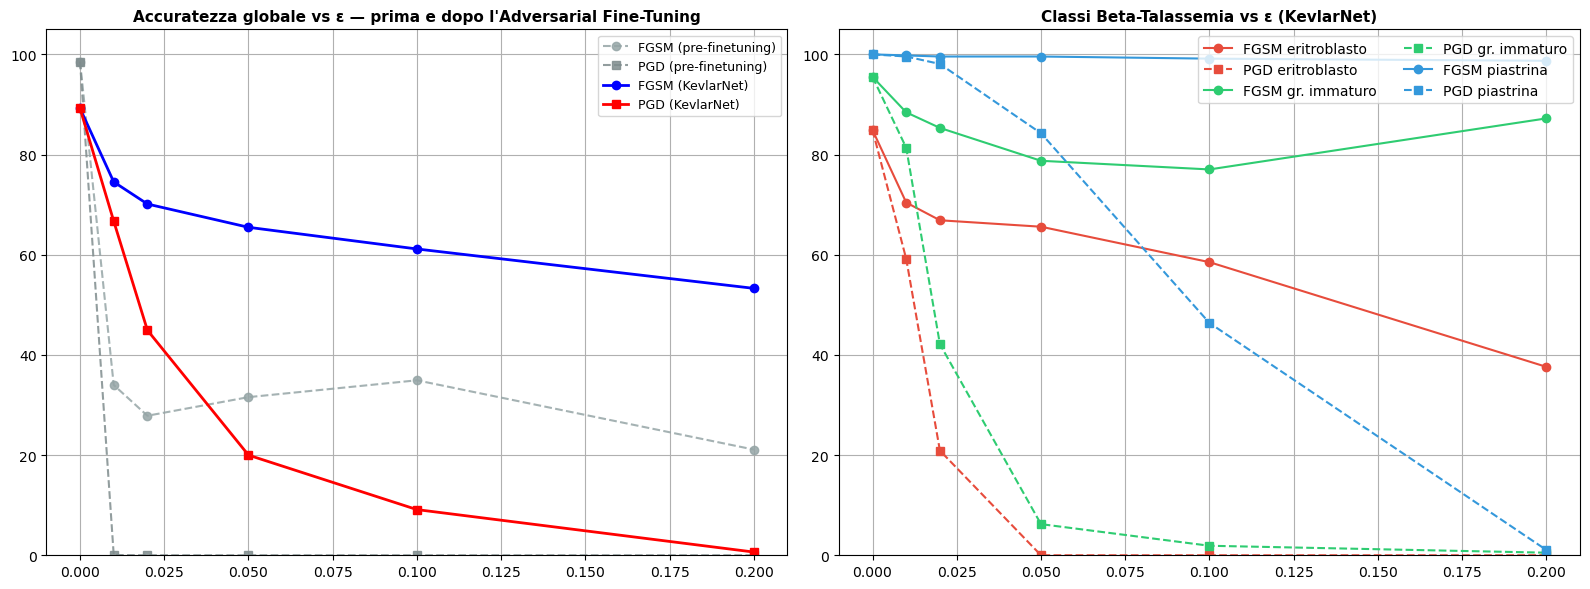

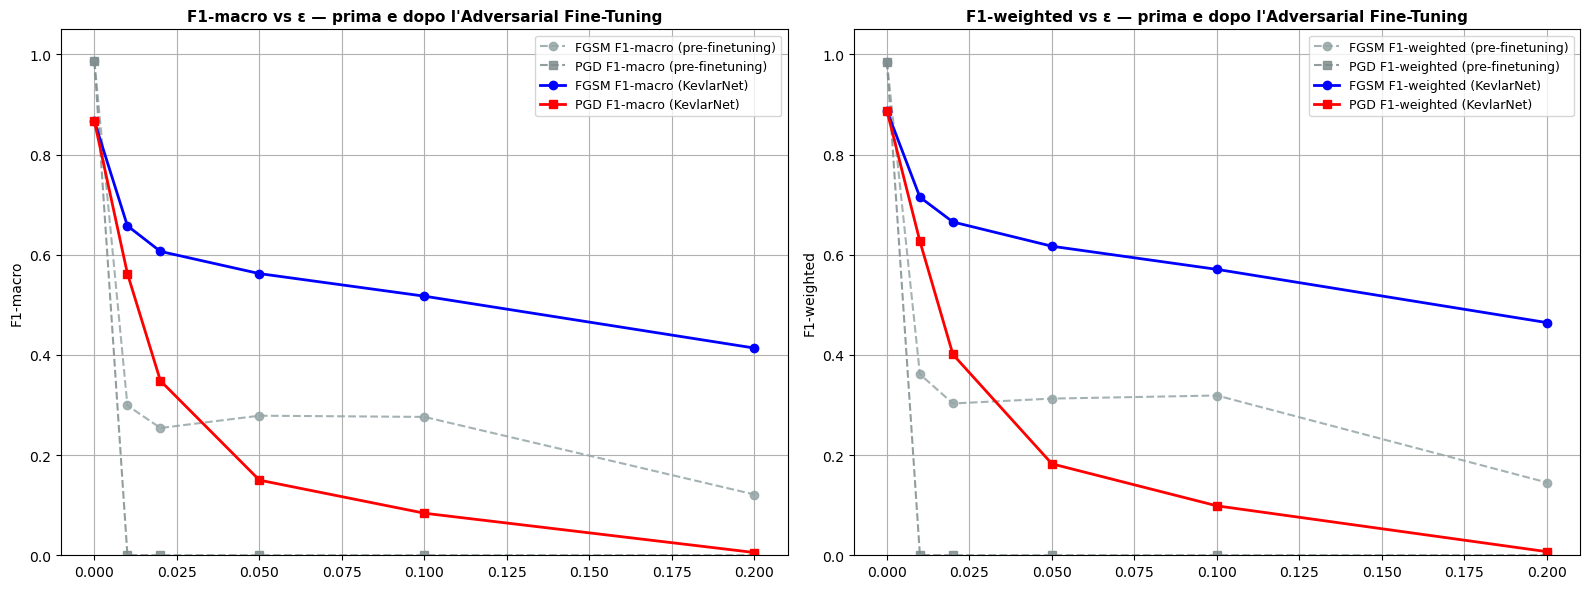


Accuratezza clean: 98.57% (pre-finetuning) → 89.21% (KevlarNet)


In [7]:
epsilons = [0, 0.01, 0.02, 0.05, 0.1, 0.2]
PGD_ALPHA = 0.01  
PGD_STEPS = 10

fgsm_acc, fgsm_per_class = [], []
pgd_acc, pgd_per_class = [], []
fgsm_acc_pre, pgd_acc_pre = [], []


fgsm_f1_macro, fgsm_f1_weighted = [], []
pgd_f1_macro, pgd_f1_weighted = [], []
fgsm_f1_macro_pre, fgsm_f1_weighted_pre = [], []
pgd_f1_macro_pre, pgd_f1_weighted_pre = [], []

print('\n=== Valutazione FGSM e PGD vs Epsilon — KevlarNet vs pre-finetuning ===')
for eps in epsilons:
    acc_f, per_cls_f, preds_f, labels_f = evaluate_adversarial_fgsm(model, test_loader, eps, criterion)
    acc_p, per_cls_p, preds_p, labels_p = evaluate_adversarial_pgd(model, test_loader, eps, PGD_ALPHA, PGD_STEPS, criterion)
    acc_f_pre, _, preds_f_pre, labels_f_pre = evaluate_adversarial_fgsm(model_pre_adv, test_loader, eps, criterion)
    acc_p_pre, _, preds_p_pre, labels_p_pre = evaluate_adversarial_pgd(model_pre_adv, test_loader, eps, PGD_ALPHA, PGD_STEPS, criterion)

    fgsm_acc.append(acc_f); fgsm_per_class.append(per_cls_f)
    pgd_acc.append(acc_p);  pgd_per_class.append(per_cls_p)
    fgsm_acc_pre.append(acc_f_pre)
    pgd_acc_pre.append(acc_p_pre)

    fgsm_f1_macro.append(f1_score(labels_f, preds_f, average='macro', zero_division=0))
    fgsm_f1_weighted.append(f1_score(labels_f, preds_f, average='weighted', zero_division=0))
    pgd_f1_macro.append(f1_score(labels_p, preds_p, average='macro', zero_division=0))
    pgd_f1_weighted.append(f1_score(labels_p, preds_p, average='weighted', zero_division=0))

    fgsm_f1_macro_pre.append(f1_score(labels_f_pre, preds_f_pre, average='macro', zero_division=0))
    fgsm_f1_weighted_pre.append(f1_score(labels_f_pre, preds_f_pre, average='weighted', zero_division=0))
    pgd_f1_macro_pre.append(f1_score(labels_p_pre, preds_p_pre, average='macro', zero_division=0))
    pgd_f1_weighted_pre.append(f1_score(labels_p_pre, preds_p_pre, average='weighted', zero_division=0))

    print(f'ε={eps:.2f} → KevlarNet: FGSM {acc_f*100:5.2f}% PGD {acc_p*100:5.2f}%  |  '
          f'Pre-FT: FGSM {acc_f_pre*100:5.2f}% PGD {acc_p_pre*100:5.2f}%')

_, clean_acc, clean_preds, clean_labels = evaluate(model, test_loader, criterion)
_, clean_acc_pre, _, _ = evaluate(model_pre_adv, test_loader, criterion)

print('\nFGSM — F1-macro / F1-weighted vs ε')
print(f'{"ε":>6} | {"acc pre":>8} | {"F1m pre":>8} | {"F1w pre":>8} | {"acc Kevlar":>10} | {"F1m Kevlar":>10} | {"F1w Kevlar":>10}')
print('-' * 78)
for i, eps in enumerate(epsilons):
    print(f'{eps:6.2f} | {fgsm_acc_pre[i]*100:7.2f}% | {fgsm_f1_macro_pre[i]:8.4f} | {fgsm_f1_weighted_pre[i]:8.4f} | '
          f'{fgsm_acc[i]*100:9.2f}% | {fgsm_f1_macro[i]:10.4f} | {fgsm_f1_weighted[i]:10.4f}')

print('\nPGD — F1-macro / F1-weighted vs ε')
print(f'{"ε":>6} | {"acc pre":>8} | {"F1m pre":>8} | {"F1w pre":>8} | {"acc Kevlar":>10} | {"F1m Kevlar":>10} | {"F1w Kevlar":>10}')
print('-' * 78)
for i, eps in enumerate(epsilons):
    print(f'{eps:6.2f} | {pgd_acc_pre[i]*100:7.2f}% | {pgd_f1_macro_pre[i]:8.4f} | {pgd_f1_weighted_pre[i]:8.4f} | '
          f'{pgd_acc[i]*100:9.2f}% | {pgd_f1_macro[i]:10.4f} | {pgd_f1_weighted[i]:10.4f}')


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(epsilons, [a*100 for a in fgsm_acc_pre], 'o--', color='#95a5a6', label='FGSM (pre-finetuning)', lw=1.5, alpha=0.85)
axes[0].plot(epsilons, [a*100 for a in pgd_acc_pre], 's--', color='#7f8c8d', label='PGD (pre-finetuning)', lw=1.5, alpha=0.85)
axes[0].plot(epsilons, [a*100 for a in fgsm_acc], 'b-o', label='FGSM (KevlarNet)', lw=2)
axes[0].plot(epsilons, [a*100 for a in pgd_acc], 'r-s', label='PGD (KevlarNet)', lw=2)
axes[0].set_title('Accuratezza globale vs ε — prima e dopo l\'Adversarial Fine-Tuning', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 105); axes[0].grid(True); axes[0].legend(fontsize=9)

colors_thal = ['#e74c3c', '#2ecc71', '#3498db']
for i, (c, name) in enumerate(THAL_CLASSES.items()):
    axes[1].plot(epsilons, [fgsm_per_class[j][c]*100 for j in range(len(epsilons))], f'-o', color=colors_thal[i], label=f'FGSM {name}')
    axes[1].plot(epsilons, [pgd_per_class[j][c]*100 for j in range(len(epsilons))], f'--s', color=colors_thal[i], label=f'PGD {name}')
axes[1].set_title('Classi Beta-Talassemia vs ε (KevlarNet)', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, 105); axes[1].grid(True); axes[1].legend(ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'epsilon_curves_kevlarnet.png'), dpi=150, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(epsilons, fgsm_f1_macro_pre, 'o--', color='#95a5a6', label='FGSM F1-macro (pre-finetuning)', lw=1.5, alpha=0.85)
axes[0].plot(epsilons, pgd_f1_macro_pre, 's--', color='#7f8c8d', label='PGD F1-macro (pre-finetuning)', lw=1.5, alpha=0.85)
axes[0].plot(epsilons, fgsm_f1_macro, 'b-o', label='FGSM F1-macro (KevlarNet)', lw=2)
axes[0].plot(epsilons, pgd_f1_macro, 'r-s', label='PGD F1-macro (KevlarNet)', lw=2)
axes[0].set_title('F1-macro vs ε — prima e dopo l\'Adversarial Fine-Tuning', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 1.05); axes[0].grid(True); axes[0].legend(fontsize=9)
axes[0].set_ylabel('F1-macro')

axes[1].plot(epsilons, fgsm_f1_weighted_pre, 'o--', color='#95a5a6', label='FGSM F1-weighted (pre-finetuning)', lw=1.5, alpha=0.85)
axes[1].plot(epsilons, pgd_f1_weighted_pre, 's--', color='#7f8c8d', label='PGD F1-weighted (pre-finetuning)', lw=1.5, alpha=0.85)
axes[1].plot(epsilons, fgsm_f1_weighted, 'b-o', label='FGSM F1-weighted (KevlarNet)', lw=2)
axes[1].plot(epsilons, pgd_f1_weighted, 'r-s', label='PGD F1-weighted (KevlarNet)', lw=2)
axes[1].set_title('F1-weighted vs ε — prima e dopo l\'Adversarial Fine-Tuning', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, 1.05); axes[1].grid(True); axes[1].legend(fontsize=9)
axes[1].set_ylabel('F1-weighted')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'f1_vs_epsilon_kevlarnet.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAccuratezza clean: {clean_acc_pre*100:.2f}% (pre-finetuning) → {clean_acc*100:.2f}% (KevlarNet)')


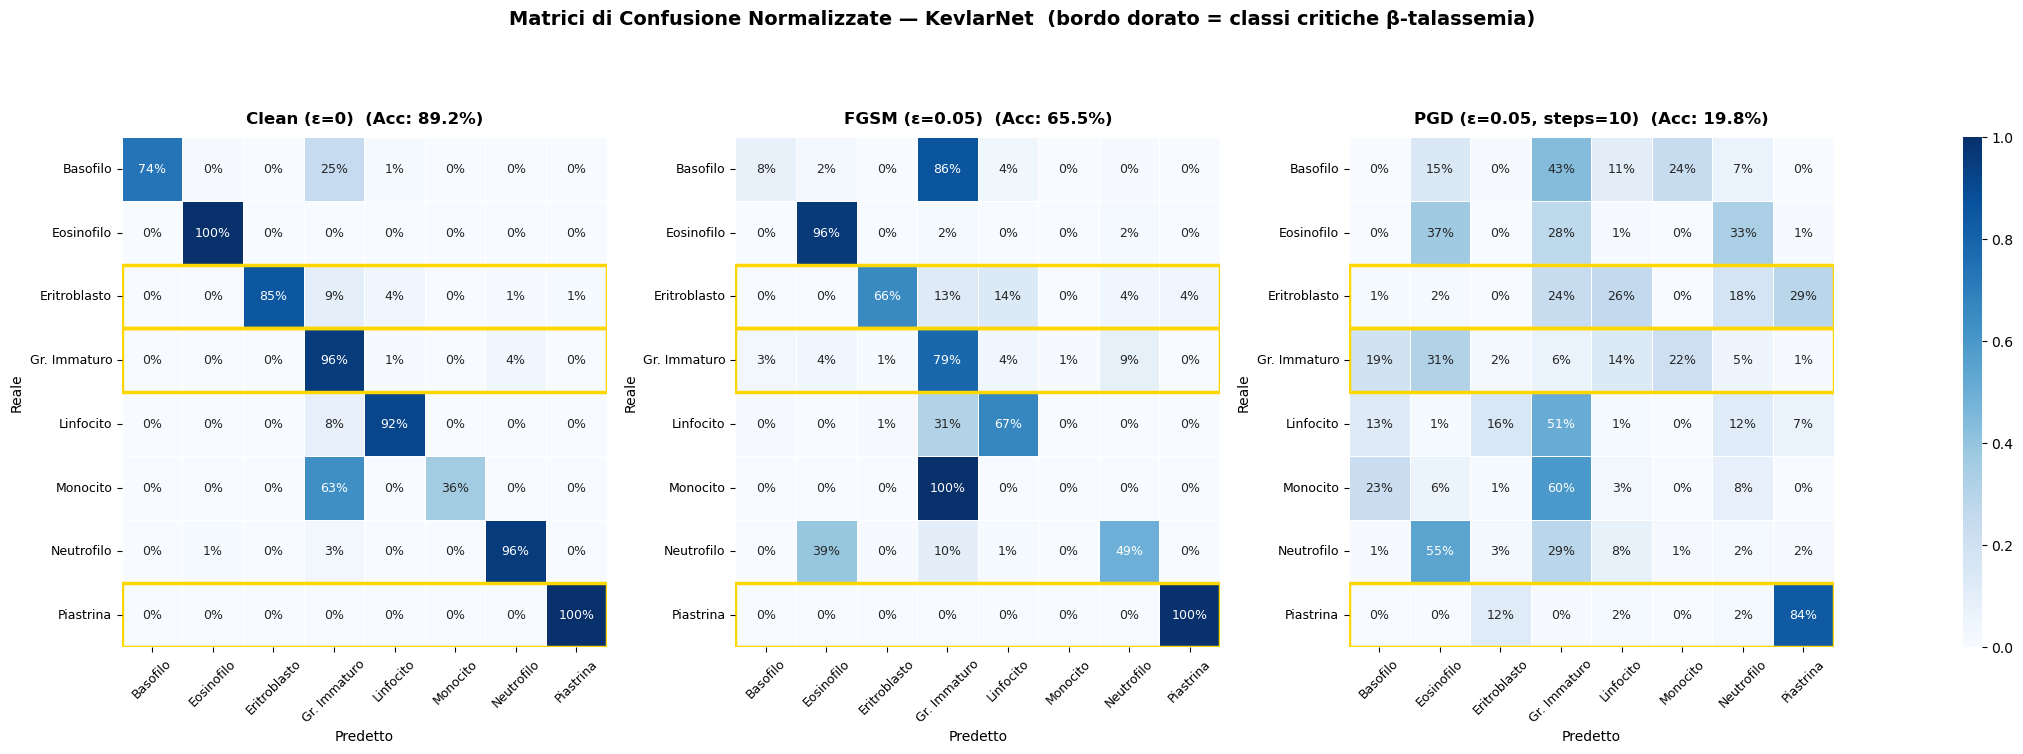

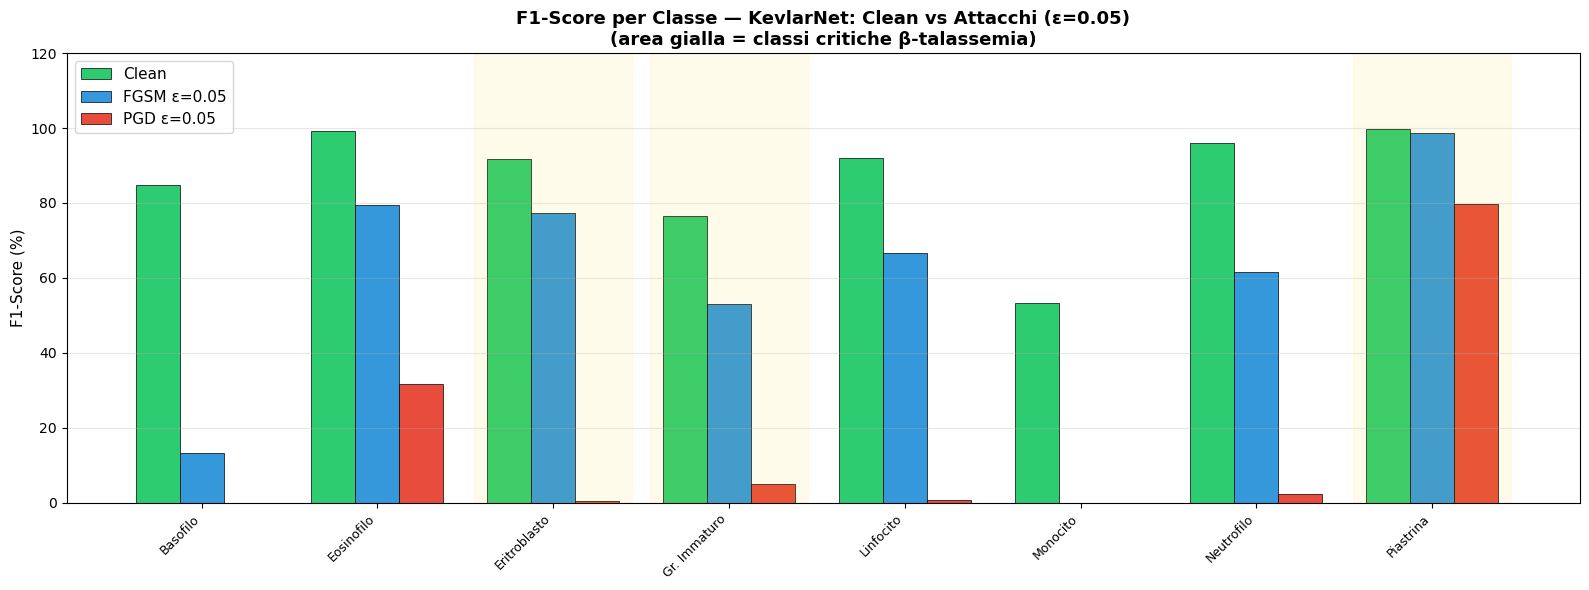


             |   F1-macro |  F1-weighted
----------------------------------------
Clean        |     0.8665 |       0.8876
FGSM ε=0.05  |     0.5623 |       0.6170
PGD ε=0.05   |     0.1502 |       0.1815


In [8]:

EPS_REPORT = 0.05


SHORT_NAMES = ['Basofilo', 'Eosinofilo', 'Eritroblasto', 'Gr. Immaturo',
               'Linfocito', 'Monocito', 'Neutrofilo', 'Piastrina']

def _attack_predictions(model, loader, attack_fn, **attack_kwargs):
    model.eval()
    preds, labels = [], []
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.squeeze().long().to(DEVICE)
        imgs_adv = attack_fn(model, imgs, lbls, criterion=criterion, **attack_kwargs)
        with torch.no_grad():
            preds.extend(model(imgs_adv).argmax(1).cpu().numpy())
        labels.extend(lbls.cpu().numpy())
    return np.array(preds), np.array(labels)

fgsm_preds_r, fgsm_labels_r = _attack_predictions(model, test_loader, fgsm_attack, epsilon=EPS_REPORT)
pgd_preds_r,  pgd_labels_r  = _attack_predictions(model, test_loader, pgd_attack,
                                                   epsilon=EPS_REPORT, alpha=PGD_ALPHA, n_steps=PGD_STEPS)

def plot_cm(labels, preds, title, ax, cbar_ax=None):
    cm = confusion_matrix(labels, preds, labels=range(len(SHORT_NAMES)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    acc = (preds == labels).mean()
    sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='Blues',
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
                ax=ax, linewidths=0.6, linecolor='white', vmin=0, vmax=1,
                cbar=cbar_ax is not None, cbar_ax=cbar_ax,
                annot_kws={'fontsize': 9})
    ax.set_title(f'{title}  (Acc: {acc:.1%})', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predetto', fontsize=10); ax.set_ylabel('Reale', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)
    for idx in THAL_CLASSES:
        ax.add_patch(plt.Rectangle((0, idx), len(SHORT_NAMES), 1, fill=False, edgecolor='gold', lw=2.5))

fig = plt.figure(figsize=(24, 7.5))
gs_cm = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.04], wspace=0.35, top=0.80, bottom=0.12)
axes = [fig.add_subplot(gs_cm[0, i]) for i in range(3)]
cax = fig.add_subplot(gs_cm[0, 3])

plot_cm(clean_labels, clean_preds, 'Clean (ε=0)', axes[0])
plot_cm(fgsm_labels_r, fgsm_preds_r, f'FGSM (ε={EPS_REPORT})', axes[1])
plot_cm(pgd_labels_r, pgd_preds_r, f'PGD (ε={EPS_REPORT}, steps={PGD_STEPS})', axes[2], cbar_ax=cax)

fig.suptitle('Matrici di Confusione Normalizzate — KevlarNet  (bordo dorato = classi critiche β-talassemia)',
             fontsize=14, fontweight='bold', y=0.97)
plt.savefig(os.path.join(IMAGES_DIR, 'confusion_matrices_kevlarnet.png'), dpi=150, bbox_inches='tight')
plt.show()


f1_clean_r = f1_score(clean_labels, clean_preds, average=None, zero_division=0)
f1_fgsm_r  = f1_score(fgsm_labels_r, fgsm_preds_r, average=None, zero_division=0)
f1_pgd_r   = f1_score(pgd_labels_r, pgd_preds_r, average=None, zero_division=0)

x = np.arange(len(SHORT_NAMES)); width = 0.25
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, f1_clean_r * 100, width, label='Clean', color='#2ecc71', edgecolor='black', lw=0.5)
ax.bar(x,          f1_fgsm_r  * 100, width, label=f'FGSM ε={EPS_REPORT}', color='#3498db', edgecolor='black', lw=0.5)
ax.bar(x + width,  f1_pgd_r   * 100, width, label=f'PGD ε={EPS_REPORT}', color='#e74c3c', edgecolor='black', lw=0.5)
for idx in THAL_CLASSES:
    ax.axvspan(idx - 0.45, idx + 0.45, alpha=0.08, color='gold')
ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1-Score (%)', fontsize=11)
ax.set_title(f'F1-Score per Classe — KevlarNet: Clean vs Attacchi (ε={EPS_REPORT})\n'
             '(area gialla = classi critiche β-talassemia)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 120); ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'f1_kevlarnet.png'), dpi=150, bbox_inches='tight')
plt.show()


f1_macro_clean = f1_score(clean_labels, clean_preds, average='macro', zero_division=0)
f1_macro_fgsm  = f1_score(fgsm_labels_r, fgsm_preds_r, average='macro', zero_division=0)
f1_macro_pgd   = f1_score(pgd_labels_r, pgd_preds_r, average='macro', zero_division=0)

f1_weighted_clean = f1_score(clean_labels, clean_preds, average='weighted', zero_division=0)
f1_weighted_fgsm  = f1_score(fgsm_labels_r, fgsm_preds_r, average='weighted', zero_division=0)
f1_weighted_pgd   = f1_score(pgd_labels_r, pgd_preds_r, average='weighted', zero_division=0)

macro_f1_clean = f1_macro_clean  

print(f'\n{"":<12} | {"F1-macro":>10} | {"F1-weighted":>12}')
print('-' * 40)
print(f'{"Clean":<12} | {f1_macro_clean:>10.4f} | {f1_weighted_clean:>12.4f}')
print(f'{"FGSM ε=0.05":<12} | {f1_macro_fgsm:>10.4f} | {f1_weighted_fgsm:>12.4f}')
print(f'{"PGD ε=0.05":<12} | {f1_macro_pgd:>10.4f} | {f1_weighted_pgd:>12.4f}')


## Componente Avanzata — Spiegabilità Visiva (Grad-CAM)
Confermiamo visivamente che KevlarNet, addestrata avversarialmente, basa le sue predizioni sulla **morfologia cellulare al centro** e ignora i pixel di sfondo.



Avvio dell'analisi Grad-CAM su KevlarNet
Raccolti campioni sufficienti per tutte le classi.
Creazione del grafico boxplot...


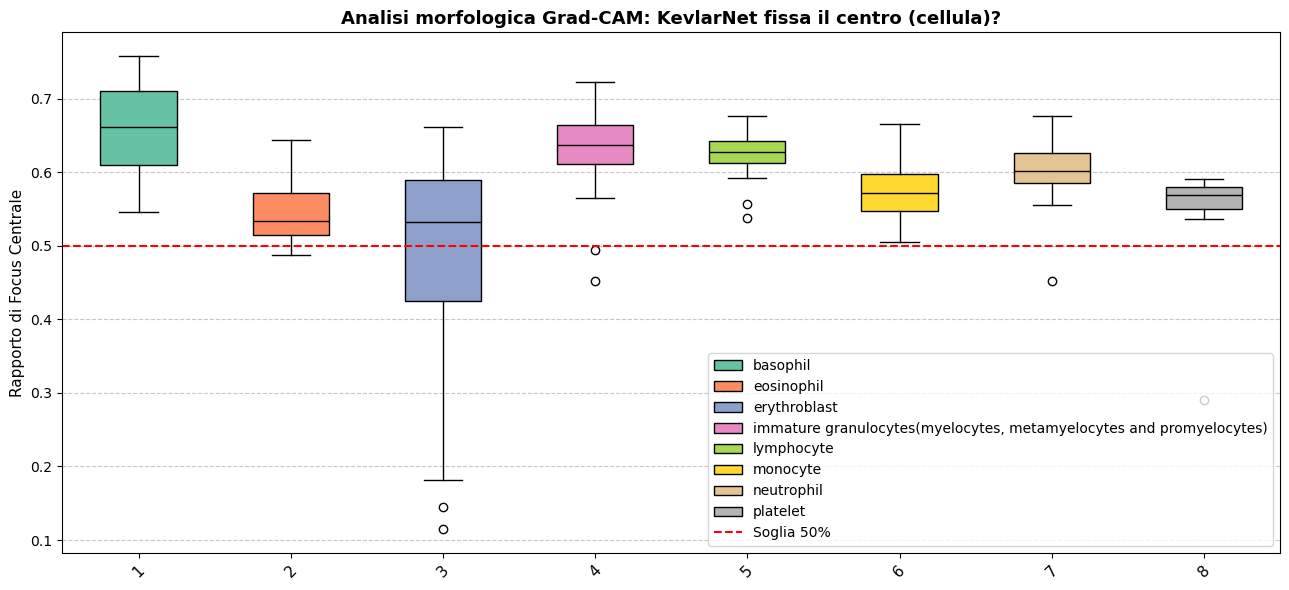

In [9]:

import torch.nn.functional as F
from typing import Optional

class GradCAM:
    
    def __init__(self, model: torch.nn.Module, target_layer: torch.nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor: torch.Tensor, target_class: Optional[int] = None, size: tuple = (224, 224)) -> tuple:
        self.model.eval()
        input_tensor.requires_grad_(True)

        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError("Gradienti o attivazioni non catturati. Controlla il target_layer.")

        gradients = self.gradients.detach()
        activations = self.activations.detach()

        # Pesi (Global Average Pooling): media lungo Altezza e Larghezza -> (1, C, 1, 1)
        weights = torch.mean(gradients, dim=[2, 3], keepdim=True)

        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = torch.relu(cam)

        # Normalizzazione Min-Max
        cam_min, cam_max = cam.min(), cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        cam = F.interpolate(cam, size=size, mode='bilinear', align_corners=False)

        return cam.squeeze().cpu().numpy(), target_class


def cam_center_ratio(cam: np.ndarray, center_frac: float = 0.5) -> float:
    """Calcola il rapporto tra l'intensità della CAM nella regione centrale e totale."""
    h, w = cam.shape
    ch = int(h * (1 - center_frac) / 2)
    cw = int(w * (1 - center_frac) / 2)
    center_region = cam[ch:h - ch, cw:w - cw]
    return float(center_region.sum() / (cam.sum() + 1e-8))



gradcam = GradCAM(model, model.features[-1][0])


vis_dataset_norm = BloodMNIST(split='test', transform=transforms.ToTensor(), download=True, size=224)

center_ratios = {name: [] for name in CLASS_NAMES}
counts_cls = {i: 0 for i in range(len(CLASS_NAMES))}
n_samples_per_class = 20
img_size = 224

print("\nAvvio dell'analisi Grad-CAM su KevlarNet")

for img_raw, label in vis_dataset_norm:

    cls_idx = int(label.item() if hasattr(label, 'item') else label[0])

    if counts_cls[cls_idx] >= n_samples_per_class:
        continue

    img_norm = transform_test(transforms.ToPILImage()(img_raw))
    inp = img_norm.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(inp).argmax(dim=1).item()

    if pred == cls_idx:
        cam, _ = gradcam.generate(inp, target_class=cls_idx, size=(img_size, img_size))
        ratio = cam_center_ratio(cam)
        center_ratios[CLASS_NAMES[cls_idx]].append(ratio)
        counts_cls[cls_idx] += 1

    if all(v >= n_samples_per_class for v in counts_cls.values()):
        print("Raccolti campioni sufficienti per tutte le classi.")
        break

# --- Visualizzazione dei Risultati ---
print("Creazione del grafico boxplot...")
fig, ax = plt.subplots(figsize=(13, 6))
data_plot = [center_ratios[name] for name in CLASS_NAMES]
bp = ax.boxplot(data_plot, label=CLASS_NAMES, patch_artist=True, medianprops={'color': 'black'})

safe_set2_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']

if len(CLASS_NAMES) > len(safe_set2_colors):
    safe_set2_colors = safe_set2_colors * (len(CLASS_NAMES) // len(safe_set2_colors) + 1)

for patch, color in zip(bp['boxes'], safe_set2_colors):
    patch.set_facecolor(color)

ax.axhline(y=0.5, color='red', linestyle='--', lw=1.5, label='Soglia 50%')
ax.set_title('Analisi morfologica Grad-CAM: KevlarNet fissa il centro (cellula)?', fontsize=13, fontweight='bold')
ax.set_ylabel('Rapporto di Focus Centrale', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'gradcam_morphology_analysis_mobilenetv2.png'), dpi=150, bbox_inches='tight')
plt.show()


In [10]:

print('\n' + '=' * 65)
print('     RIEPILOGO PROGETTO BloodMNIST — KevlarNet (MobileNetV2)')
print('=' * 65)
print(f'Modello:           MobileNetV2 "KevlarNet" con Adversarial Fine-Tuning')
print(f'Accuratezza clean: {clean_acc_pre*100:.2f}% (pre-finetuning) → {clean_acc*100:.2f}% (KevlarNet)')
print(f'F1-macro clean:    {f1_macro_clean:.4f}  |  F1-weighted clean: {f1_weighted_clean:.4f}  (KevlarNet)')

print(f'\n--- Robustezza avversariale (α={PGD_ALPHA}, PGD steps={PGD_STEPS}) — accuracy pre-FT → KevlarNet ---')
print(f'{"ε":>6} | {"FGSM pre":>9} | {"FGSM Kevlar":>12} | {"PGD pre":>9} | {"PGD Kevlar":>11}')
print('-' * 58)
for eps, fp, fk, pp, pk in zip(epsilons, fgsm_acc_pre, fgsm_acc, pgd_acc_pre, pgd_acc):
    print(f'{eps:6.2f} | {fp*100:8.2f}% | {fk*100:11.2f}% | {pp*100:8.2f}% | {pk*100:10.2f}%')

print(f'\n--- F1-macro — pre-FT → KevlarNet ---')
print(f'{"ε":>6} | {"FGSM pre":>9} | {"FGSM Kevlar":>12} | {"PGD pre":>9} | {"PGD Kevlar":>11}')
print('-' * 58)
for eps, fp, fk, pp, pk in zip(epsilons, fgsm_f1_macro_pre, fgsm_f1_macro, pgd_f1_macro_pre, pgd_f1_macro):
    print(f'{eps:6.2f} | {fp:9.4f} | {fk:12.4f} | {pp:9.4f} | {pk:11.4f}')

print(f'\n--- F1-weighted — pre-FT → KevlarNet ---')
print(f'{"ε":>6} | {"FGSM pre":>9} | {"FGSM Kevlar":>12} | {"PGD pre":>9} | {"PGD Kevlar":>11}')
print('-' * 58)
for eps, fp, fk, pp, pk in zip(epsilons, fgsm_f1_weighted_pre, fgsm_f1_weighted, pgd_f1_weighted_pre, pgd_f1_weighted):
    print(f'{eps:6.2f} | {fp:9.4f} | {fk:12.4f} | {pp:9.4f} | {pk:11.4f}')

print('=' * 65)
print(f'Checkpoint pre-finetuning: {GS_CKPT_PATH}')
print(f'Checkpoint KevlarNet:      {ADV_CKPT_PATH}')
print(f'Figure salvate in:         {IMAGES_DIR}')



     RIEPILOGO PROGETTO BloodMNIST — KevlarNet (MobileNetV2)
Modello:           MobileNetV2 "KevlarNet" con Adversarial Fine-Tuning
Accuratezza clean: 98.57% (pre-finetuning) → 89.21% (KevlarNet)
F1-macro clean:    0.8665  |  F1-weighted clean: 0.8876  (KevlarNet)

--- Robustezza avversariale (α=0.01, PGD steps=10) — accuracy pre-FT → KevlarNet ---
     ε |  FGSM pre |  FGSM Kevlar |   PGD pre |  PGD Kevlar
----------------------------------------------------------
  0.00 |    98.57% |       89.21% |    98.57% |      89.21%
  0.01 |    34.00% |       74.54% |     0.06% |      66.71%
  0.02 |    27.86% |       70.13% |     0.00% |      44.93%
  0.05 |    31.57% |       65.48% |     0.00% |      19.99%
  0.10 |    34.93% |       61.15% |     0.00% |       9.12%
  0.20 |    21.10% |       53.29% |     0.00% |       0.64%

--- F1-macro — pre-FT → KevlarNet ---
     ε |  FGSM pre |  FGSM Kevlar |   PGD pre |  PGD Kevlar
----------------------------------------------------------
  0.00 |   